# FashionMNIST Image Classification with PyTorch

**Samantha Kanny**
**CSCI E-89 Deep Learning**
**Homework 03, Problem 3**
**FashionMNIST Image Classification with PyTorch**

This notebook builds a fully connected neural network to classify FashionMNIST images using PyTorch. It covers data loading, model definition, training, evaluation, hyperparameter tuning with Optuna, model saving/loading, and inference optimization.

## 1. Import Packages

Import all packages needed for data loading, modeling, training, metrics, visualization, and hyperparameter tuning.

In [1]:
import random

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
from torchvision.datasets import FashionMNIST
import torchmetrics
from torchmetrics.classification import MulticlassAccuracy
import matplotlib.pyplot as plt
import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner

## 2. Set Random Seed

Set the random seed to 42 across Python's `random`, NumPy, and PyTorch for reproducibility.

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

## 3. Select Device

Use CUDA when available, Apple MPS when available, and fall back to the CPU otherwise.

In [3]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")

Using device: cpu


## 4. Download and Load the FashionMNIST Dataset

Download the FashionMNIST training and test sets using TorchVision. `transforms.ToTensor()` converts the images to `torch.float32` tensors and scales pixel values from `[0, 255]` to `[0.0, 1.0]`.

In [4]:
transform = transforms.ToTensor()

full_train_dataset = FashionMNIST(root="data", train=True, download=True, transform=transform)
test_dataset = FashionMNIST(root="data", train=False, download=True, transform=transform)

print(f"Full training dataset size: {len(full_train_dataset)}")
print(f"Test dataset size: {len(test_dataset)}")

Full training dataset size: 60000
Test dataset size: 10000


## 5. Split Training Data into Training and Validation Sets

Split the 60,000 original training observations into 55,000 training observations and 5,000 validation observations using a seeded generator for reproducibility.

In [5]:
train_size = 55000
val_size = 5000

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

print(f"Training set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")

Training set size: 55000
Validation set size: 5000


## 6. Create DataLoaders

Create training, validation, and test DataLoaders with a batch size of 32. Only the training data is shuffled.

In [6]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Number of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")

Number of training batches: 1719
Number of validation batches: 157
Number of test batches: 313


## 7. Inspect a Sample Image

Display a sample image's shape, data type, numerical label, and FashionMNIST class name.

Image shape: torch.Size([1, 28, 28])
Image dtype: torch.float32
Numerical label: 9
Class name: Ankle boot


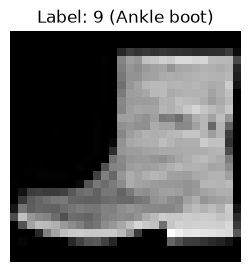

In [7]:
sample_image, sample_label = train_dataset[0]
class_names = full_train_dataset.classes

print(f"Image shape: {sample_image.shape}")
print(f"Image dtype: {sample_image.dtype}")
print(f"Numerical label: {sample_label}")
print(f"Class name: {class_names[sample_label]}")

plt.figure(figsize=(3, 3))
plt.imshow(sample_image.squeeze(), cmap="gray")
plt.title(f"Label: {sample_label} ({class_names[sample_label]})")
plt.axis("off")
plt.show()

## 8. Define the `ImageClassifier` Model

Define a fully connected neural network named `ImageClassifier` with:
- A flattening layer
- A linear layer from 784 inputs to 300 hidden units
- A ReLU activation
- A linear layer from 300 to 100 hidden units
- A ReLU activation
- A final linear layer with 10 outputs

The number of hidden units in each layer is configurable so the same class can be reused during hyperparameter tuning.

In [8]:
class ImageClassifier(nn.Module):
    def __init__(self, hidden_units_1=300, hidden_units_2=100, num_classes=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(28 * 28, hidden_units_1)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_units_1, hidden_units_2)
        self.relu2 = nn.ReLU()
        self.fc3 = nn.Linear(hidden_units_2, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x


model = ImageClassifier().to(device)
print(model)

ImageClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=300, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=300, out_features=100, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)


## 9. Loss Function, Optimizer, and Metric

Use cross-entropy loss, stochastic gradient descent (SGD), and multiclass accuracy from TorchMetrics.

In [9]:
LEARNING_RATE = 0.1

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=LEARNING_RATE)
accuracy_metric = MulticlassAccuracy(num_classes=10).to(device)

print("Loss function:", loss_fn)
print("Optimizer:", optimizer)
print("Accuracy metric:", accuracy_metric)

Loss function: CrossEntropyLoss()
Optimizer: SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.1
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)
Accuracy metric: MulticlassAccuracy()


## 10. Reusable Training and Validation Functions

Define reusable functions to train for one epoch and to evaluate a model on a given DataLoader.

In [10]:
def train_one_epoch(model, dataloader, loss_fn, optimizer, accuracy_metric, device):
    model.train()
    accuracy_metric.reset()
    running_loss = 0.0

    for images, labels in dataloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        accuracy_metric.update(outputs, labels)

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_metric.compute().item()
    return epoch_loss, epoch_acc


def evaluate(model, dataloader, loss_fn, accuracy_metric, device):
    model.eval()
    accuracy_metric.reset()
    running_loss = 0.0

    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = loss_fn(outputs, labels)

            running_loss += loss.item() * images.size(0)
            accuracy_metric.update(outputs, labels)

    epoch_loss = running_loss / len(dataloader.dataset)
    epoch_acc = accuracy_metric.compute().item()
    return epoch_loss, epoch_acc

## 11. Train the Model

Train the model and record training loss, validation loss, training accuracy, and validation accuracy for every epoch. Results are printed after each epoch.

In [11]:
NUM_EPOCHS = 10

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, loss_fn, optimizer, accuracy_metric, device)
    val_loss, val_acc = evaluate(model, val_loader, loss_fn, accuracy_metric, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
    )

Epoch 1/10 | Train Loss: 0.6062 | Train Acc: 0.7811 | Val Loss: 0.4504 | Val Acc: 0.8429


Epoch 2/10 | Train Loss: 0.4062 | Train Acc: 0.8496 | Val Loss: 0.4327 | Val Acc: 0.8432


Epoch 3/10 | Train Loss: 0.3638 | Train Acc: 0.8659 | Val Loss: 0.3882 | Val Acc: 0.8548


Epoch 4/10 | Train Loss: 0.3352 | Train Acc: 0.8769 | Val Loss: 0.3707 | Val Acc: 0.8669


Epoch 5/10 | Train Loss: 0.3150 | Train Acc: 0.8834 | Val Loss: 0.3447 | Val Acc: 0.8758


Epoch 6/10 | Train Loss: 0.2991 | Train Acc: 0.8872 | Val Loss: 0.3575 | Val Acc: 0.8675


Epoch 7/10 | Train Loss: 0.2860 | Train Acc: 0.8922 | Val Loss: 0.3364 | Val Acc: 0.8764


Epoch 8/10 | Train Loss: 0.2758 | Train Acc: 0.8965 | Val Loss: 0.3339 | Val Acc: 0.8753


Epoch 9/10 | Train Loss: 0.2637 | Train Acc: 0.9007 | Val Loss: 0.3355 | Val Acc: 0.8810


Epoch 10/10 | Train Loss: 0.2525 | Train Acc: 0.9050 | Val Loss: 0.3402 | Val Acc: 0.8767


## 12. Plot Training and Validation Accuracy

Plot training accuracy and validation accuracy across epochs for comparison.

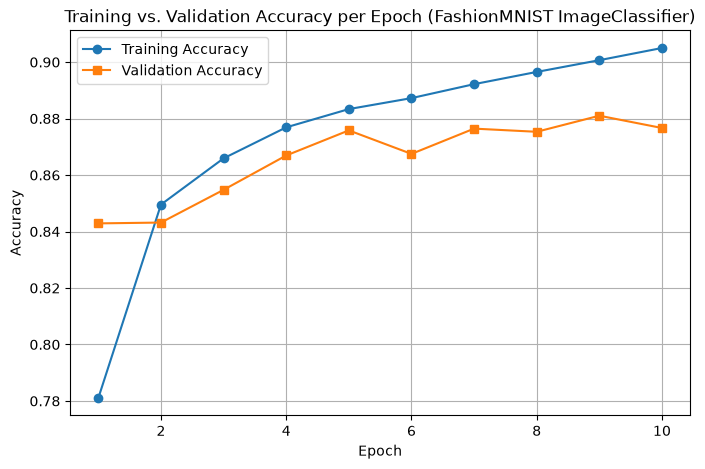

In [12]:
epochs_range = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, history["train_acc"], marker="o", label="Training Accuracy")
plt.plot(epochs_range, history["val_acc"], marker="s", label="Validation Accuracy")
plt.title("Training vs. Validation Accuracy per Epoch (FashionMNIST ImageClassifier)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

## 13. Evaluate the Trained Model on the Test Set

Evaluate the trained model's loss and accuracy on the held-out test images.

In [13]:
test_loss, test_acc = evaluate(model, test_loader, loss_fn, accuracy_metric, device)
print(f"Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

Test Loss: 0.3555 | Test Accuracy: 0.8705


## 14. Display Predictions on Sample Images

Display predicted labels, predicted class names, actual labels, and actual class names for a batch of test images.

In [14]:
model.eval()
images, labels = next(iter(test_loader))
images_device = images.to(device)

with torch.no_grad():
    logits = model(images_device)

predicted_labels = torch.argmax(logits, dim=1).cpu()

NUM_SAMPLES_TO_SHOW = 8
for i in range(NUM_SAMPLES_TO_SHOW):
    pred_label = predicted_labels[i].item()
    true_label = labels[i].item()
    print(
        f"Image {i}: Predicted = {pred_label} ({class_names[pred_label]}) | "
        f"Actual = {true_label} ({class_names[true_label]})"
    )

Image 0: Predicted = 9 (Ankle boot) | Actual = 9 (Ankle boot)
Image 1: Predicted = 2 (Pullover) | Actual = 2 (Pullover)
Image 2: Predicted = 1 (Trouser) | Actual = 1 (Trouser)
Image 3: Predicted = 1 (Trouser) | Actual = 1 (Trouser)
Image 4: Predicted = 6 (Shirt) | Actual = 6 (Shirt)
Image 5: Predicted = 1 (Trouser) | Actual = 1 (Trouser)
Image 6: Predicted = 4 (Coat) | Actual = 4 (Coat)
Image 7: Predicted = 6 (Shirt) | Actual = 6 (Shirt)


## 15. Calculate Softmax Probabilities

Convert the model's raw logits into class probabilities using the softmax function.

In [15]:
probabilities = torch.softmax(logits, dim=1)

for i in range(NUM_SAMPLES_TO_SHOW):
    print(f"Image {i} probabilities: {probabilities[i].cpu().detach().numpy().round(4)}")

Image 0 probabilities: [0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 5.00e-04 0.00e+00 1.25e-02
 0.00e+00 9.87e-01]
Image 1 probabilities: [0.000e+00 0.000e+00 9.988e-01 0.000e+00 1.100e-03 0.000e+00 1.000e-04
 0.000e+00 0.000e+00 0.000e+00]
Image 2 probabilities: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
Image 3 probabilities: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
Image 4 probabilities: [6.600e-02 0.000e+00 2.300e-03 2.000e-04 6.000e-04 0.000e+00 9.309e-01
 0.000e+00 0.000e+00 0.000e+00]
Image 5 probabilities: [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
Image 6 probabilities: [0.000e+00 0.000e+00 4.000e-04 0.000e+00 9.985e-01 0.000e+00 1.200e-03
 0.000e+00 0.000e+00 0.000e+00]
Image 7 probabilities: [0.000e+00 0.000e+00 1.000e-04 0.000e+00 1.700e-02 0.000e+00 9.829e-01
 0.000e+00 0.000e+00 0.000e+00]


## 16. Top-4 Predictions with `torch.topk()`

Use `torch.topk()` to display the four highest-probability classes for the selected images.

In [16]:
top4_probs, top4_indices = torch.topk(probabilities, k=4, dim=1)

for i in range(NUM_SAMPLES_TO_SHOW):
    print(f"Image {i} (Actual: {class_names[labels[i].item()]}) - Top 4 predictions:")
    for prob, idx in zip(top4_probs[i], top4_indices[i]):
        print(f"    {class_names[idx.item()]}: {prob.item():.4f}")

Image 0 (Actual: Ankle boot) - Top 4 predictions:
    Ankle boot: 0.9870
    Sneaker: 0.0125
    Sandal: 0.0005
    Trouser: 0.0000
Image 1 (Actual: Pullover) - Top 4 predictions:
    Pullover: 0.9988
    Coat: 0.0011
    Shirt: 0.0001
    T-shirt/top: 0.0000
Image 2 (Actual: Trouser) - Top 4 predictions:
    Trouser: 1.0000
    T-shirt/top: 0.0000
    Shirt: 0.0000
    Dress: 0.0000
Image 3 (Actual: Trouser) - Top 4 predictions:
    Trouser: 1.0000
    Dress: 0.0000
    T-shirt/top: 0.0000
    Shirt: 0.0000
Image 4 (Actual: Shirt) - Top 4 predictions:
    Shirt: 0.9309
    T-shirt/top: 0.0660
    Pullover: 0.0023
    Coat: 0.0006
Image 5 (Actual: Trouser) - Top 4 predictions:
    Trouser: 1.0000
    T-shirt/top: 0.0000
    Shirt: 0.0000
    Dress: 0.0000
Image 6 (Actual: Coat) - Top 4 predictions:
    Coat: 0.9985
    Shirt: 0.0012
    Pullover: 0.0004
    Dress: 0.0000
Image 7 (Actual: Shirt) - Top 4 predictions:
    Shirt: 0.9829
    Coat: 0.0170
    Pullover: 0.0001
    T-shirt/top

## 17. Model Parameter Count

Display the model's total number of parameters.

In [17]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Total parameters: 266,610
Trainable parameters: 266,610


## 18. Hyperparameter Tuning with Optuna

Use Optuna to tune the learning rate and the number of hidden units in each layer of `ImageClassifier`. A `TPESampler` with a fixed seed makes the search reproducible, and a `MedianPruner` prunes unpromising trials early based on intermediate validation accuracy.

In [18]:
def objective(trial):
    lr = trial.suggest_float("lr", 1e-4, 1e-1, log=True)
    hidden_units_1 = trial.suggest_categorical("hidden_units_1", [64, 128, 256, 300, 512])
    hidden_units_2 = trial.suggest_categorical("hidden_units_2", [32, 64, 100, 128, 256])

    trial_model = ImageClassifier(hidden_units_1=hidden_units_1, hidden_units_2=hidden_units_2).to(device)
    trial_optimizer = optim.SGD(trial_model.parameters(), lr=lr)
    trial_loss_fn = nn.CrossEntropyLoss()
    trial_metric = MulticlassAccuracy(num_classes=10).to(device)

    n_trial_epochs = 3
    val_acc = 0.0
    for epoch in range(n_trial_epochs):
        train_one_epoch(trial_model, train_loader, trial_loss_fn, trial_optimizer, trial_metric, device)
        _, val_acc = evaluate(trial_model, val_loader, trial_loss_fn, trial_metric, device)

        trial.report(val_acc, epoch)
        if trial.should_prune():
            raise optuna.TrialPruned()

    return val_acc


sampler = TPESampler(seed=SEED)
pruner = MedianPruner(n_startup_trials=2, n_warmup_steps=1)
study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=10)

print("Best hyperparameters:", study.best_params)
print(f"Best validation accuracy: {study.best_value:.4f}")

[I 2026-09-20 20:00:40,038] A new study created in memory with name: no-name-a1581ce3-6357-422a-9d23-54ac506ac472


[I 2026-09-20 20:00:52,669] Trial 0 finished with value: 0.6594732999801636 and parameters: {'lr': 0.0013292918943162175, 'hidden_units_1': 64, 'hidden_units_2': 64}. Best is trial 0 with value: 0.6594732999801636.


[I 2026-09-20 20:01:05,724] Trial 1 finished with value: 0.856130063533783 and parameters: {'lr': 0.0812324508558869, 'hidden_units_1': 64, 'hidden_units_2': 128}. Best is trial 1 with value: 0.856130063533783.


[I 2026-09-20 20:01:14,948] Trial 2 pruned. 


[I 2026-09-20 20:01:27,471] Trial 3 finished with value: 0.8579788208007812 and parameters: {'lr': 0.07025166339242159, 'hidden_units_1': 64, 'hidden_units_2': 256}. Best is trial 3 with value: 0.8579788208007812.


...

[I 2026-09-20 20:02:00,023] Trial 6 pruned. 


[I 2026-09-20 20:02:10,444] Trial 7 pruned. 


[I 2026-09-20 20:02:20,161] Trial 8 pruned. 


[I 2026-09-20 20:02:29,980] Trial 9 pruned. 


Best hyperparameters: {'lr': 0.07025166339242159, 'hidden_units_1': 64, 'hidden_units_2': 256}
Best validation accuracy: 0.8580


## 19. Save and Reload the Complete Model

Demonstrate saving the entire model (architecture and weights) and reloading it.

In [19]:
FULL_MODEL_PATH = "fashion_mnist_full_model.pth"
torch.save(model, FULL_MODEL_PATH)

loaded_full_model = torch.load(FULL_MODEL_PATH, weights_only=False, map_location=device)
loaded_full_model.eval()

print("Full model reloaded successfully:")
print(loaded_full_model)

Full model reloaded successfully:
ImageClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=300, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=300, out_features=100, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)


## 20. Save and Reload Only the Model Weights

Demonstrate saving and reloading only the model's `state_dict` (weights).

In [20]:
WEIGHTS_PATH = "fashion_mnist_weights.pth"
torch.save(model.state_dict(), WEIGHTS_PATH)

new_model = ImageClassifier().to(device)
new_model.load_state_dict(torch.load(WEIGHTS_PATH, weights_only=True, map_location=device))
new_model.eval()

print("Model weights reloaded successfully into a fresh ImageClassifier instance.")

Model weights reloaded successfully into a fresh ImageClassifier instance.


## 21. Save Weights with Architecture Hyperparameters

Save the model weights together with the architecture hyperparameters, then reconstruct the model from the saved information.

In [21]:
CHECKPOINT_PATH = "fashion_mnist_checkpoint.pth"

checkpoint = {
    "state_dict": model.state_dict(),
    "hidden_units_1": 300,
    "hidden_units_2": 100,
    "num_classes": 10,
}
torch.save(checkpoint, CHECKPOINT_PATH)

loaded_checkpoint = torch.load(CHECKPOINT_PATH, weights_only=True, map_location=device)
reconstructed_model = ImageClassifier(
    hidden_units_1=loaded_checkpoint["hidden_units_1"],
    hidden_units_2=loaded_checkpoint["hidden_units_2"],
    num_classes=loaded_checkpoint["num_classes"],
).to(device)
reconstructed_model.load_state_dict(loaded_checkpoint["state_dict"])
reconstructed_model.eval()

print("Model reconstructed from checkpoint with architecture hyperparameters.")
print(reconstructed_model)

Model reconstructed from checkpoint with architecture hyperparameters.
ImageClassifier(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=784, out_features=300, bias=True)
  (relu1): ReLU()
  (fc2): Linear(in_features=300, out_features=100, bias=True)
  (relu2): ReLU()
  (fc3): Linear(in_features=100, out_features=10, bias=True)
)


## 22. Optimize the Model for Inference

Use `torch.compile()`, PyTorch's current, non-deprecated method for optimizing a model graph, to produce an optimized version of the model for inference.

In [22]:
model.eval()
compiled_model = torch.compile(model)

with torch.no_grad():
    _ = compiled_model(images_device)  # trigger compilation

print("Model compiled for optimized inference using torch.compile().")

Model compiled for optimized inference using torch.compile().


## 23. Compare Original and Optimized Model Predictions

Compare predictions from the original and the `torch.compile()`-optimized model to confirm they are consistent.

In [23]:
model.eval()
compiled_model.eval()

with torch.no_grad():
    original_logits = model(images_device)
    compiled_logits = compiled_model(images_device)

original_preds = torch.argmax(original_logits, dim=1)
compiled_preds = torch.argmax(compiled_logits, dim=1)

print("Original model predictions: ", original_preds.cpu().tolist())
print("Compiled model predictions:", compiled_preds.cpu().tolist())
print("Predictions match:", torch.equal(original_preds, compiled_preds))

Original model predictions:  [9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 7, 3, 4, 1, 2, 2, 8, 0, 2, 5, 7, 5, 1, 2, 6, 0, 9, 4, 8, 8]
Compiled model predictions: [9, 2, 1, 1, 6, 1, 4, 6, 5, 7, 4, 5, 7, 3, 4, 1, 2, 2, 8, 0, 2, 5, 7, 5, 1, 2, 6, 0, 9, 4, 8, 8]
Predictions match: True
